# Random Forests from Scratch — A Hands-On Tutorial

*Turn one shaky decision tree into a confident committee of hundreds — using only NumPy — and watch a jagged boundary melt into a smooth one.*

---

## Overview

This tutorial turns a compact `random_forest.py` script into a complete, visual learning experience. It is the natural sequel to the **Decision Tree** notebook: a random forest is simply **many trees voting together**.

- **What it teaches:** how **bagging** (bootstrap aggregating) and **feature randomness** combine many high-variance trees into one low-variance, accurate model, and how **out-of-bag (OOB)** samples give you free validation.
- **Who it's for:** beginners and intermediate learners who understand a single decision tree and want to see why *ensembles* dominate tabular machine learning.
- **ML task type:** **Classification** — predicting a *category / label*. (Forests handle **2 or more** classes natively.)

### Learning outcomes
By the end you will be able to:
1. Explain the **"wisdom of the crowd"**: why averaging many diverse trees beats any single tree.
2. Describe **bagging** (bootstrap samples) and **feature subsampling**, and why both create *diversity*.
3. Use the **out-of-bag score** as a built-in validation estimate.
4. Show that a forest **resists overfitting** where a single deep tree fails, and evaluate with **accuracy, precision, recall, F1**, a **confusion matrix**, and **ROC-AUC**.

### What you will build
A from-scratch `RandomForest` class (built on a from-scratch `DecisionTree`) that mirrors the sklearn API — `fit` / `predict` / `predict_proba` — reports an **`oob_score_`**, aggregates **`feature_importances_`**, and drives charts including the **single-tree-vs-forest** comparison, a **confusion matrix**, and **animations** of the boundary smoothing as trees are added.

> **How to use this notebook (read me first)**
> - Run the cells **in order, top to bottom** — in VS Code click **▶▶ Run All**.
> - Every code cell is followed by a short **plain-English explanation**.
> - The **animations** have a ▶ play button — press it to watch the idea move.
> - Look for the **"Key insight"** lines: each is the single thing to remember from that chart.
> - Sections are numbered **1 → 16**; read the concept (1–2) first, then the code builds up step by step.


## 1. The concept in plain language

A single decision tree is **smart but unstable**: change a few training points and it can grow a very different shape. It has **high variance** — it tends to **overfit**. A **Random Forest** fixes this with the oldest trick in statistics: **ask many and average**.

> Ask one expert and you get one opinion (possibly quirky). Ask **hundreds of slightly different experts** and average their votes, and the quirks cancel out while the signal survives. That is a random forest.

To make the trees **diverse** (so their errors are independent and cancel), a forest injects **two kinds of randomness**:

1. **Bagging (Bootstrap AGGregating):** each tree is trained on a **bootstrap sample** — a random draw of $n$ points *with replacement* from the training set. Every tree sees a slightly different dataset.
2. **Feature randomness:** at **each split**, a tree may only choose from a **random subset** of the features (typically $\sqrt{\#\text{features}}$). This stops one strong feature from dominating every tree and **decorrelates** them.

To predict, the forest lets every tree vote and takes the **majority** (or averages the class probabilities).

### Why averaging works — variance, not bias
Averaging $T$ independent estimates cuts their variance by roughly $1/T$ **without adding bias**. Bagging deliberately builds **deep, low-bias, high-variance** trees, then averages the variance away. The result: **lower error and far more stability** than any single tree.

### Out-of-bag (OOB) validation — a free lunch
A bootstrap sample leaves out about **37%** of the data (the "out-of-bag" points) for each tree. Each point can be predicted using only the trees that **didn't** see it — giving an honest accuracy estimate **without a separate validation set**.

### Everyday examples
Forests are the go-to model for messy tabular data:

| Domain | Input features (x) | Predicted class (ŷ) |
|--------|--------------------|----------------------|
| Banking | income, debt, history | approve vs decline |
| Medicine | many test measurements | disease vs healthy |
| E-commerce | browsing + purchase history | will buy vs won't |
| Insurance | claim + policy features | fraud vs legitimate |
| Ecology | climate + soil features | species present vs absent |
| Telecom | usage + billing features | churn vs stay |
| Manufacturing | many sensor readings | defect vs OK |

### Two simple analogies
1. **Wisdom of the crowd.** At a fair, no single person guesses the jar's jelly-bean count well — but the **average** of hundreds of guesses is uncannily accurate. Each tree is one guesser.
2. **A panel of doctors.** One doctor might over-react to a quirk in your chart. A **panel** that votes — each having seen slightly different cases — gives a diagnosis you can trust.

### Key terms
- **Ensemble** — a model made of many sub-models whose outputs are combined.
- **Bagging** — training each sub-model on a bootstrap (resampled) dataset.
- **Bootstrap sample** — $n$ points drawn with replacement (~63% unique, ~37% left out).
- **Feature subsampling** — considering only a random subset of features per split.
- **Out-of-bag (OOB) score** — validation accuracy from each point's non-training trees.
- **Variance reduction** — the core benefit: averaging tames a single tree's instability.


### See it — averaging tames the wobble

Before any model code, here is the whole idea in one picture. Below, each **thin grey line** is a single "tree-like" estimator: a jumpy, piecewise-constant guess of a smooth trend — individually **high variance** and jagged (just like one deep decision tree). Watch what happens as we **average more and more of them**: the red mean line converges to the smooth truth.

**Learning objective:** see that averaging many noisy, high-variance estimators cancels their errors and recovers the signal — the engine behind bagging. (Press ▶ to play.)


In [1]:
# Self-contained intuition demo (imports here so it runs even before Setup)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

rng = np.random.default_rng(0)
xg = np.linspace(0, 2 * np.pi, 200)
truth = np.sin(xg)

def weak_estimator():
    """A jumpy piecewise-constant guess (like one over-grown tree)."""
    n_breaks = rng.integers(4, 9)
    edges = np.sort(rng.uniform(0, 2 * np.pi, n_breaks))
    edges = np.concatenate([[0], edges, [2 * np.pi]])
    est = np.empty_like(xg)
    for a, b in zip(edges[:-1], edges[1:]):
        mask = (xg >= a) & (xg <= b)
        if mask.any():
            noisy = np.sin(xg[mask]) + rng.normal(0, 0.6, mask.sum())
            est[mask] = noisy.mean()          # constant = noisy average in this segment
    return est

estimators = [weak_estimator() for _ in range(60)]
cum_counts = [1, 2, 3, 5, 8, 12, 20, 30, 45, 60]

fig, ax = plt.subplots(figsize=(8, 5))

def draw(i):
    ax.clear()
    k = cum_counts[i]
    for e in estimators[:min(k, 12)]:
        ax.plot(xg, e, color="gray", alpha=0.25, lw=1)
    mean_est = np.mean(estimators[:k], axis=0)
    ax.plot(xg, truth, color="black", lw=2.5, label="true signal")
    ax.plot(xg, mean_est, color="crimson", lw=2.5, label=f"average of {k} estimators")
    ax.set_title(f"Averaging {k} high-variance estimators -> the wobble cancels out")
    ax.set_xlabel("x"); ax.set_ylabel("prediction")
    ax.set_ylim(-2.2, 2.2); ax.legend(loc="upper right")

crowd_anim = animation.FuncAnimation(fig, draw, frames=len(cum_counts), interval=650)
plt.close(fig)  # avoid a duplicate static figure
HTML(crowd_anim.to_jshtml())


**What to notice:** any single grey estimator is jumpy and often far from the truth — **high variance**. Yet as we average more of them, the red line **smooths out and locks onto the true curve**. The individual errors are random and cancel; the shared signal reinforces. Swap "estimator" for "decision tree" and you have a random forest.


## 2. The machine-learning workflow

Almost every supervised-learning project follows the same path. Here is how this notebook maps onto it:

```mermaid
flowchart LR
    A[Load / generate data] --> B[Explore the data]
    B --> C[Train / test split]
    C --> D[Bootstrap + grow many trees]
    D --> E[Vote / average predictions]
    E --> F[Evaluate - accuracy, F1, OOB, ROC-AUC]
    F --> G[Visualise boundary & importances]
    G --> H[Tune n_trees, depth, max_features]
```

| Step | What it means | Where in this notebook |
|------|---------------|------------------------|
| Data loading | Get labelled examples to learn from | Section 6 |
| Data exploration (EDA) | Look at shape, class balance, separation | Section 7 |
| Train/test split | Hold out data for honest evaluation | Section 6 |
| Model training | Bootstrap + grow diverse trees | Section 8 |
| Prediction | Majority vote / average probabilities | Section 8 |
| Evaluation | accuracy, F1, **OOB**, ROC-AUC | Section 9 |
| Interpretation | Boundary, single-vs-forest, importances | Sections 10–12 |

**Note on feature scaling:** like single trees, random forests are **scale-invariant** — every split just compares a feature to a threshold, so **no `StandardScaler` is needed**. The knobs that matter are **`n_trees`** (more is better, then plateaus — never overfits from count alone), **`max_depth`** (per-tree complexity), and **`max_features`** (how much randomness/decorrelation per split).


## 3. Setup — import the tools

We use a small, standard stack:

- **NumPy** — the array math behind bootstrapping, trees and voting.
- **pandas** — to hold the data as a table for quick exploration.
- **Matplotlib / seaborn** — for the charts and animations.
- **scikit-learn** — *only* to generate/load datasets and split them. **Both the tree and the forest are written from scratch.**

> If a package is missing, install it once with:
> `pip install numpy pandas matplotlib seaborn scikit-learn plotly`


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split

# Nicer default styling for all plots
sns.set_theme(style="whitegrid")
%matplotlib inline


## 4. Evaluation metrics (defined first so we can reuse them)

For **classification** we judge the model with a family of related numbers, all built from the **confusion matrix** $M$, where $M_{t,p}$ counts points with true class $t$ predicted as $p$.

$$\text{accuracy} = \frac{\text{correct}}{\text{total}} \qquad \text{precision}_c = \frac{TP_c}{TP_c+FP_c} \qquad \text{recall}_c = \frac{TP_c}{TP_c+FN_c}$$

$$F1_c = 2\cdot\frac{\text{precision}_c\cdot\text{recall}_c}{\text{precision}_c+\text{recall}_c}$$

- **Accuracy** — overall fraction correct (fair when classes are balanced).
- **Precision / Recall / F1** — computed **per class**, then **macro-averaged** so each class counts equally.

> These work for **any number of classes**, with a tiny `eps` guarding the denominators.


In [3]:
def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray,
                     labels: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Build a confusion matrix ``M`` where ``M[t, p]`` counts true ``t`` predicted ``p``.

    Parameters
    ----------
    y_true, y_pred : array-like of shape (n_samples,)
        Ground-truth and predicted class labels.
    labels : np.ndarray, optional
        Ordered class labels; inferred from the data if not given.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        The ``(k, k)`` count matrix and the array of labels (its row/col order).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    index = {label: i for i, label in enumerate(labels)}
    M = np.zeros((len(labels), len(labels)), dtype=int)
    for t, p in zip(y_true, y_pred):
        M[index[t], index[p]] += 1
    return M, labels


def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Fraction of predictions that exactly match the truth."""
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


def precision_recall_f1(y_true: np.ndarray, y_pred: np.ndarray,
                        labels: np.ndarray | None = None) -> tuple[float, float, float, pd.DataFrame]:
    """Macro-averaged precision, recall and F1, plus a per-class table.

    Returns
    -------
    tuple[float, float, float, pandas.DataFrame]
        ``(macro_precision, macro_recall, macro_f1, per_class_table)``.
    """
    M, labels = confusion_matrix(y_true, y_pred, labels)
    eps = 1e-12
    tp = np.diag(M).astype(float)
    fp = M.sum(axis=0) - tp
    fn = M.sum(axis=1) - tp
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    table = pd.DataFrame({"precision": precision, "recall": recall, "f1": f1},
                         index=[f"class {c}" for c in labels]).round(3)
    return float(precision.mean()), float(recall.mean()), float(f1.mean()), table


**What just happened:** three dependency-free helpers. `confusion_matrix` tallies every true/predicted pair; `accuracy` is the overall hit-rate; `precision_recall_f1` derives per-class scores plus their **macro averages** and a tidy table. We'll reuse them to score both the single tree and the forest.


## 5. The model — a Decision Tree, then a Random Forest

A forest is built *from* trees, so we need both. First the **`DecisionTree`** (the same from-scratch tree as the Decision Tree notebook, which already supports **per-split feature subsampling** via `n_feats` — exactly what a forest needs). Then the **`RandomForest`** that bags and votes.

### The decision tree (recap)
Grows greedily by **information gain** (entropy/Gini), splits on feature-threshold midpoints, and — crucially for forests — can restrict each split to a **random subset of `n_feats` features**.


In [4]:
from collections import Counter


class Node:
    """A tree node: an internal question, or a leaf holding a prediction + class proba."""

    def __init__(self, feature=None, threshold=None, left=None, right=None,
                 *, value=None, proba=None) -> None:
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.proba = proba

    def is_leaf(self) -> bool:
        return self.value is not None


class DecisionTree:
    """CART-style decision tree grown greedily by information gain.

    Supports per-split **feature subsampling** (``n_feats``) so it can act as a
    base learner inside a random forest.

    Parameters
    ----------
    max_depth : int, default 100
    min_samples_split : int, default 2
    criterion : {"entropy", "gini"}, default "entropy"
    n_feats : int, optional
        Random features considered per split (all features if ``None``).
    random_state : int, optional
        Seed for the feature subsampling.
    """

    def __init__(self, max_depth: int = 100, min_samples_split: int = 2,
                 criterion: str = "entropy", n_feats: int | None = None,
                 random_state: int | None = None) -> None:
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.n_feats = n_feats
        self.random_state = random_state
        self.root = None
        self.classes_ = None
        self.feature_importances_ = None

    def _impurity(self, y: np.ndarray) -> float:
        counts = np.bincount(y, minlength=len(self.classes_))
        p = counts[counts > 0] / len(y)
        if self.criterion == "gini":
            return float(1.0 - np.sum((counts / len(y)) ** 2))
        return float(-np.sum(p * np.log2(p)))

    def fit(self, X: np.ndarray, y: np.ndarray) -> "DecisionTree":
        """Grow the tree from features ``X`` and labels ``y``; returns self."""
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self._class_index = {c: i for i, c in enumerate(self.classes_)}
        y_idx = np.array([self._class_index[v] for v in y])

        n_features = X.shape[1]
        self._n_feats = n_features if self.n_feats is None else min(self.n_feats, n_features)
        self._rng = np.random.default_rng(self.random_state)
        self._importances = np.zeros(n_features)

        self.root = self._grow(X, y_idx, depth=0)
        total = self._importances.sum()
        self.feature_importances_ = (self._importances / total) if total > 0 else self._importances
        return self

    def _grow(self, X, y, depth):
        n_samples = X.shape[0]
        n_features = X.shape[1]
        if depth >= self.max_depth or len(np.unique(y)) == 1 or n_samples < self.min_samples_split:
            return self._leaf(y)

        feat_idxs = (np.sort(self._rng.choice(n_features, self._n_feats, replace=False))
                     if self._n_feats < n_features else np.arange(n_features))

        best_gain, best_feat, best_thresh = -1.0, None, None
        parent = self._impurity(y)
        for feat in feat_idxs:
            col = X[:, feat]
            uniq = np.unique(col)
            if len(uniq) < 2:
                continue
            for thr in (uniq[:-1] + uniq[1:]) / 2.0:
                gain = self._information_gain(y, col, thr, parent)
                if gain > best_gain:
                    best_gain, best_feat, best_thresh = gain, feat, thr

        if best_feat is None or best_gain <= 0:
            return self._leaf(y)

        self._importances[best_feat] += best_gain * n_samples
        mask = X[:, best_feat] <= best_thresh
        left = self._grow(X[mask], y[mask], depth + 1)
        right = self._grow(X[~mask], y[~mask], depth + 1)
        return Node(best_feat, best_thresh, left, right)

    def _information_gain(self, y, col, thr, parent):
        left, right = y[col <= thr], y[col > thr]
        if len(left) == 0 or len(right) == 0:
            return 0.0
        n = len(y)
        child = (len(left) / n) * self._impurity(left) + (len(right) / n) * self._impurity(right)
        return parent - child

    def _leaf(self, y):
        counts = np.bincount(y, minlength=len(self.classes_))
        return Node(value=self.classes_[int(np.argmax(counts))], proba=counts / counts.sum())

    def _traverse(self, x, node):
        if node.is_leaf():
            return node
        return self._traverse(x, node.left if x[node.feature] <= node.threshold else node.right)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict a class label for each row of ``X``."""
        X = np.asarray(X, dtype=float)
        return np.array([self._traverse(x, self.root).value for x in X])

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Return each leaf's class-probability distribution for the rows of ``X``."""
        X = np.asarray(X, dtype=float)
        return np.array([self._traverse(x, self.root).proba for x in X])


**What just happened:** this is the decision tree from the previous notebook, unchanged. The key feature for forests is `n_feats`: when set, each split only considers that many **random** features (seeded by `random_state`), which is how a forest keeps its trees from all looking the same.


### The random forest — bag, grow, vote

Now the ensemble. `fit` grows `n_trees` trees, each on a **bootstrap sample** and each restricted to `max_features` random features per split. We also track each tree's **out-of-bag** indices to compute a free validation score.

- **`predict`** — every tree votes; return the **majority** class.
- **`predict_proba`** — **average** the trees' class probabilities (much **smoother** than one tree).
- **`oob_score_`** — accuracy from predicting each point with only the trees that didn't train on it.
- **`feature_importances_`** — the trees' importances, averaged.


In [5]:
class RandomForest:
    """A random forest classifier: bagging + per-split feature subsampling over trees.

    Parameters
    ----------
    n_trees : int, default 100
        Number of trees in the ensemble.
    max_depth : int, default 100
        Maximum depth of each tree.
    min_samples_split : int, default 2
        Minimum samples required to split a node.
    max_features : {"sqrt", "log2", int, None}, default "sqrt"
        Number of features considered at each split (the decorrelation knob).
    bootstrap : bool, default True
        Whether to train each tree on a bootstrap resample.
    random_state : int, optional
        Seed controlling bootstrapping and feature subsampling.

    Attributes
    ----------
    trees : list[DecisionTree]
        The fitted base learners.
    classes_ : np.ndarray
        Sorted class labels.
    oob_score_ : float
        Out-of-bag accuracy estimate (NaN if ``bootstrap=False``).
    feature_importances_ : np.ndarray
        Mean feature importance across trees.
    """

    def __init__(self, n_trees: int = 100, max_depth: int = 100, min_samples_split: int = 2,
                 max_features="sqrt", bootstrap: bool = True,
                 criterion: str = "entropy", random_state: int | None = None) -> None:
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.criterion = criterion
        self.random_state = random_state
        self.trees: list[DecisionTree] = []
        self.classes_ = None
        self.oob_score_ = float("nan")
        self.feature_importances_ = None

    def _resolve_max_features(self, n_features: int) -> int:
        if self.max_features == "sqrt":
            return max(1, int(np.sqrt(n_features)))
        if self.max_features == "log2":
            return max(1, int(np.log2(n_features)))
        if isinstance(self.max_features, int):
            return min(self.max_features, n_features)
        return n_features                     # None -> all features

    def fit(self, X: np.ndarray, y: np.ndarray) -> "RandomForest":
        """Grow ``n_trees`` bootstrapped trees and compute the OOB score; returns self."""
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        n_feats = self._resolve_max_features(n_features)
        rng = np.random.default_rng(self.random_state)

        self.trees = []
        oob_votes = np.zeros((n_samples, len(self.classes_)))     # accumulate OOB class votes
        for t in range(self.n_trees):
            if self.bootstrap:
                idxs = rng.choice(n_samples, n_samples, replace=True)
            else:
                idxs = np.arange(n_samples)
            tree = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split,
                                criterion=self.criterion, n_feats=n_feats,
                                random_state=int(rng.integers(1 << 31)))
            tree.fit(X[idxs], y[idxs])
            self.trees.append(tree)

            if self.bootstrap:                # tally this tree's vote on its out-of-bag points
                oob_mask = np.ones(n_samples, dtype=bool)
                oob_mask[np.unique(idxs)] = False
                if oob_mask.any():
                    preds = tree.predict(X[oob_mask])
                    for i, p in zip(np.where(oob_mask)[0], preds):
                        oob_votes[i, np.searchsorted(self.classes_, p)] += 1

        # out-of-bag accuracy: majority OOB vote vs truth, over points that were ever OOB
        if self.bootstrap:
            voted = oob_votes.sum(axis=1) > 0
            oob_pred = self.classes_[np.argmax(oob_votes[voted], axis=1)]
            self.oob_score_ = float(np.mean(oob_pred == y[voted])) if voted.any() else float("nan")

        # mean feature importance across the ensemble
        self.feature_importances_ = np.mean([tr.feature_importances_ for tr in self.trees], axis=0)
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Average the class-probability distributions of all trees (aligned to ``classes_``)."""
        if not self.trees:
            raise RuntimeError("Model is not fitted yet — call fit() before predict_proba().")
        X = np.asarray(X, dtype=float)
        agg = np.zeros((X.shape[0], len(self.classes_)))
        for tree in self.trees:
            proba = tree.predict_proba(X)
            cols = np.searchsorted(self.classes_, tree.classes_)   # align tree's classes -> forest's
            agg[:, cols] += proba
        return agg / len(self.trees)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict the majority-vote class for each row of ``X``."""
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


**What just happened:** `RandomForest.fit` loops `n_trees` times — bootstrap the data, grow a tree that only sees `max_features` random features per split, and remember which points were **out-of-bag** for that tree. After training it derives the **`oob_score_`** (free validation) and the **averaged feature importances**. `predict_proba` averages the trees' probabilities (aligning class columns in case a bootstrap sample missed a class), and `predict` takes the majority vote.


## 6. The data + train/test split

We reuse the **two interleaving moons** from the Decision Tree notebook — a **non-linear** pattern — so we can directly compare a single tree's jagged boundary with the forest's smooth one.

- `n_samples=300`, `noise=0.30` — a bit more noise, so a single tree really wants to overfit.
- `random_state=42` — reproducible data.

We hold out **25%** as a **test set** to check generalization honestly.


In [6]:
X, y = make_moons(n_samples=300, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=123, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Class balance (train):", np.bincount(y_train))


Train: (225, 2)  Test: (75, 2)
Class balance (train): [112 113]


**What just happened:** `make_moons` returned a `300 × 2` feature matrix `X` and 0/1 labels `y` in two noisy crescents. `train_test_split` shuffled and carved off 25% for testing; `stratify=y` keeps the class proportions identical in both splits.


## 7. Exploratory data analysis (EDA)

Before training we *look* at the data: shape, missing/duplicate rows, the **class balance**, and the **non-linear** crescent shape the forest must capture.


In [7]:
df = pd.DataFrame(X, columns=["feature_1", "feature_2"])
df["label"] = y

print("Shape (rows, cols):", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Class counts:")
print(df["label"].value_counts())

display(df.head())
display(df.describe().round(3))


Shape (rows, cols): (300, 3)
Missing values: 0
Duplicate rows: 0
Class counts:
label
1    150
0    150
Name: count, dtype: int64


,feature_1,feature_2,label
0,0.924865,-0.237611,1
1,2.587875,-0.112862,1
2,-0.421033,0.447485,1
3,0.693145,0.481778,0
4,1.190855,-0.525165,1


,feature_1,feature_2,label
count,300.000,300.000,300.000
mean,0.502,0.269,0.500
std,0.927,0.577,0.501
min,-1.718,-1.178,0.000
25%,-0.088,-0.117,0.000
50%,0.474,0.287,0.500
75%,1.162,0.685,1.000
max,2.827,1.769,1.000


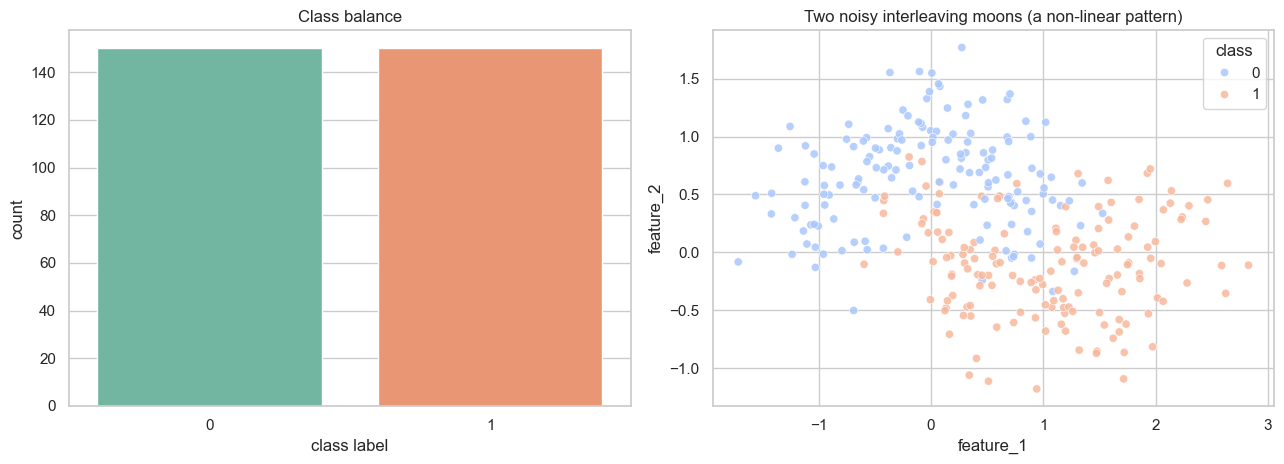

In [8]:
# Left: class balance.  Right: the two noisy moons.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.countplot(x="label", data=df, ax=axes[0], hue="label", palette="Set2", legend=False)
axes[0].set_title("Class balance")
axes[0].set_xlabel("class label"); axes[0].set_ylabel("count")

sns.scatterplot(data=df, x="feature_1", y="feature_2", hue="label",
                palette="coolwarm", alpha=0.85, ax=axes[1])
axes[1].set_title("Two noisy interleaving moons (a non-linear pattern)")
axes[1].legend(title="class")

plt.tight_layout()
plt.show()


**Key insight:** the crescents **overlap** more than before (higher noise). A single deep tree will chase that noise and overfit; the forest should **average the noise away**. The classes are balanced, so **accuracy** is a fair headline metric.


## 8. Train the model

We grow a forest of **100 trees** (each deep, each on a bootstrap sample, each split seeing $\sqrt{2}\approx1$ random feature). Because we bootstrap, we get a free **out-of-bag** accuracy estimate — no separate validation set needed.


In [9]:
forest = RandomForest(n_trees=100, max_depth=12,
                       max_features="sqrt", random_state=42).fit(X_train, y_train)

test_pred = forest.predict(X_test)
print(f"Number of trees: {len(forest.trees)}")
print(f"Out-of-bag score (free validation): {forest.oob_score_:.3f}")
print(f"Test accuracy:                      {accuracy(y_test, test_pred):.3f}")
print("First 5 predicted:", test_pred[:5], " true:", y_test[:5])


Number of trees: 100
Out-of-bag score (free validation): 0.902
Test accuracy:                      0.827
First 5 predicted: [1 0 1 1 0]  true: [0 0 1 0 0]


**What just happened:** `fit` grew 100 bootstrapped trees and, along the way, computed the **out-of-bag score** by predicting each training point with only the trees that never saw it. Notice how close the **OOB score** is to the **test accuracy** — the forest validated itself *for free*, one of its most useful practical properties.


## 9. Evaluate the model

**How to read these numbers:**
- **Accuracy** — overall fraction correct; fair here because the classes are balanced.
- **Precision / Recall / F1** — macro-averaged across classes.

Then the headline comparison of this whole notebook: a **single deep tree vs the forest** as tree depth grows. A lone tree overfits (test accuracy peaks then **drops**); the forest stays high and flat.


In [10]:
acc = accuracy(y_test, test_pred)
prec, rec, f1, per_class = precision_recall_f1(y_test, test_pred)

print(f"Accuracy:        {acc:.3f}")
print(f"Macro precision: {prec:.3f}")
print(f"Macro recall:    {rec:.3f}")
print(f"Macro F1:        {f1:.3f}\n")
display(per_class)


Accuracy:        0.827
Macro precision: 0.829
Macro recall:    0.827
Macro F1:        0.827



,precision,recall,f1
class 0,0.857,0.789,0.822
class 1,0.800,0.865,0.831


### Single tree vs forest — the variance story

We sweep `max_depth` and compare a **single decision tree** against a **forest of 60 trees** at each depth. Watch the single tree's **test** accuracy peak and then decline (overfitting), while the forest holds steady.


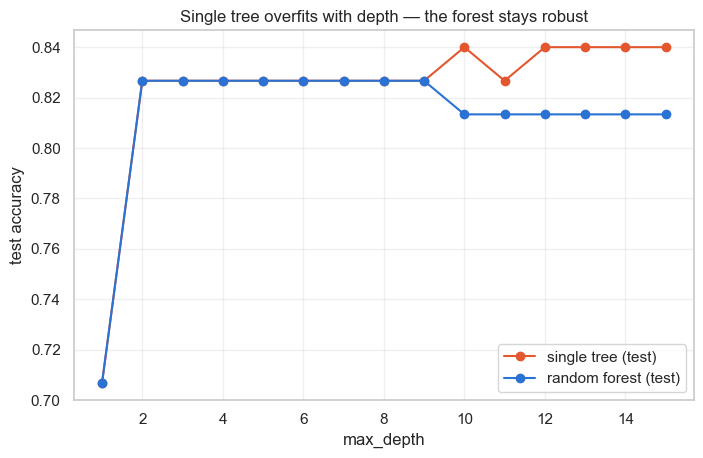

In [11]:
depths = range(1, 16)
tree_test, forest_test = [], []
for d in depths:
    single = DecisionTree(max_depth=d).fit(X_train, y_train)
    tree_test.append(accuracy(y_test, single.predict(X_test)))
    frst = RandomForest(n_trees=60, max_depth=d, max_features="sqrt", random_state=0).fit(X_train, y_train)
    forest_test.append(accuracy(y_test, frst.predict(X_test)))

plt.figure(figsize=(8, 4.8))
plt.plot(list(depths), tree_test, "o-", color="#e4572e", label="single tree (test)")
plt.plot(list(depths), forest_test, "o-", color="#2a72d4", label="random forest (test)")
plt.xlabel("max_depth"); plt.ylabel("test accuracy")
plt.title("Single tree overfits with depth — the forest stays robust")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


**Key insight:** the orange **single tree** climbs to a peak and then **degrades** as depth lets it memorise noise. The blue **forest** rises and then **plateaus at a higher level** — bagging averages away the very overfitting that hurts the lone tree. This variance reduction is the entire reason random forests exist.


## 10. Visualising results

Numbers tell us *how well*; charts tell us *how*. The clearest picture of a forest is its **smooth boundary** next to a single tree's **jagged** one.

### Single tree vs forest — decision boundary


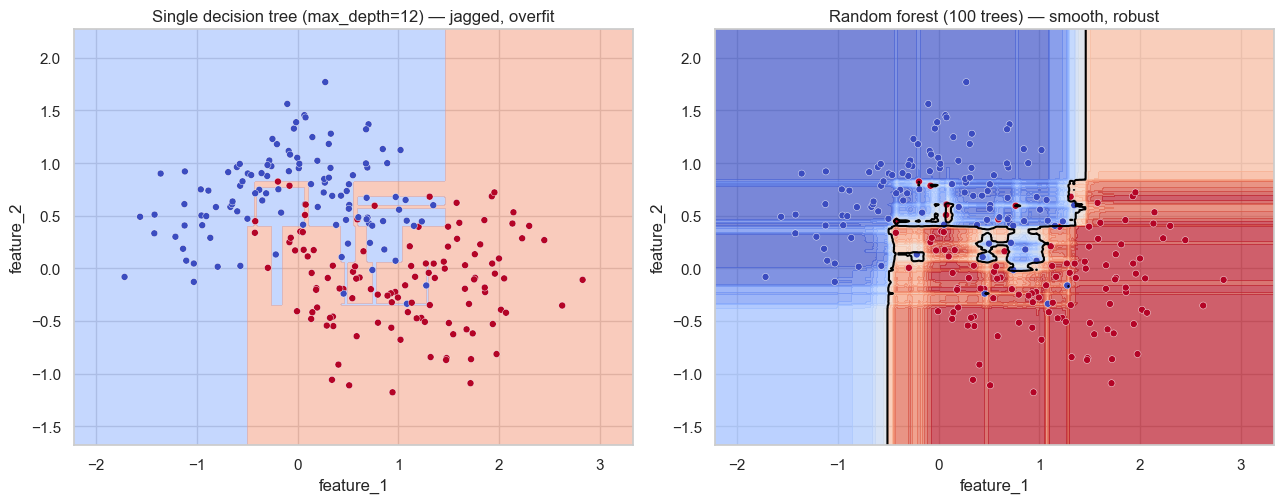

In [12]:
# Compare boundaries: one deep tree (jagged) vs the forest (smooth)
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

single = DecisionTree(max_depth=12).fit(X_train, y_train)
Z_tree = single.predict(grid).reshape(xx.shape)
Z_forest = forest.predict_proba(grid)[:, 1].reshape(xx.shape)   # smooth probability

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
axes[0].contourf(xx, yy, Z_tree, levels=[-0.5, 0.5, 1.5], cmap="coolwarm", alpha=0.5)
axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm",
                edgecolor="white", s=25, linewidth=0.3)
axes[0].set_title("Single decision tree (max_depth=12) — jagged, overfit")

cf = axes[1].contourf(xx, yy, Z_forest, levels=25, cmap="coolwarm", alpha=0.7)
axes[1].contour(xx, yy, Z_forest, levels=[0.5], colors="black", linewidths=1.5)
axes[1].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm",
                edgecolor="white", s=25, linewidth=0.3)
axes[1].set_title("Random forest (100 trees) — smooth, robust")
for a in axes:
    a.set_xlabel("feature_1"); a.set_ylabel("feature_2")
plt.tight_layout()
plt.show()


**Key insight:** the single tree's boundary (left) is a **hard, jagged staircase** with little islands around noisy points — classic overfitting. The forest (right) averages 100 such staircases into a **smooth, graded** boundary that follows the true crescent shape and expresses **uncertainty** (the pale band) instead of committing hard everywhere. Same building block, dramatically better result.

### Confusion matrix


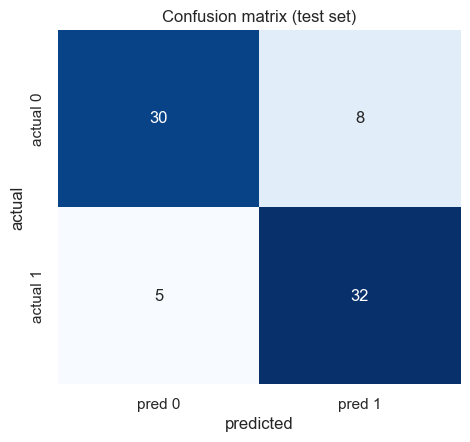

Rows = actual class, columns = predicted class


In [13]:
M, labels = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5.2, 4.6))
sns.heatmap(M, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=[f"pred {c}" for c in labels],
            yticklabels=[f"actual {c}" for c in labels])
plt.title("Confusion matrix (test set)")
plt.ylabel("actual"); plt.xlabel("predicted")
plt.show()

print("Rows = actual class, columns = predicted class")


**Key insight:** the **diagonal** entries are correct predictions; **off-diagonal** are mistakes. A near-diagonal matrix on the noisy moons shows the forest handled the overlap well.

### ROC curve — smoother than a single tree's
Because the forest **averages** many trees' probabilities, its predicted scores are **fine-grained**, giving a smooth ROC (a single tree's is coarse and step-like).


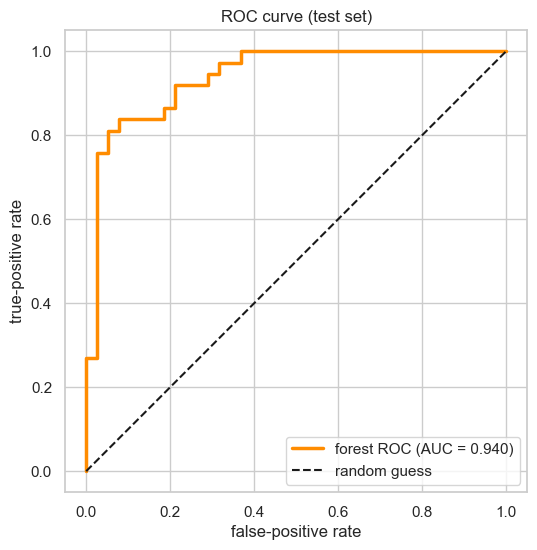

In [14]:
proba1 = forest.predict_proba(X_test)[:, list(forest.classes_).index(1)]
order = np.argsort(-proba1)
y_sorted = y_test[order]

P = np.sum(y_test == 1); N = np.sum(y_test == 0)
tpr = np.concatenate([[0], np.cumsum(y_sorted == 1) / P])
fpr = np.concatenate([[0], np.cumsum(y_sorted == 0) / N])
auc = float(np.sum(np.diff(fpr) * (tpr[:-1] + tpr[1:]) / 2))

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2.5, label=f"forest ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="random guess")
plt.xlabel("false-positive rate"); plt.ylabel("true-positive rate")
plt.title("ROC curve (test set)")
plt.legend(loc="lower right"); plt.axis("square")
plt.show()


**Key insight:** the forest's ROC is **smooth** and hugs the top-left corner — the averaged probabilities rank points finely, unlike a single tree's chunky leaf proportions. Smooth, well-ranked scores are another practical win of ensembling.


## 11. Animation — the boundary smooths as trees are added

A forest "improves" by **adding trees**. We add them one batch at a time and redraw the *averaged* boundary. Press ▶ to watch a jagged single-tree boundary melt into a smooth ensemble boundary.


In [15]:
from matplotlib import animation
from IPython.display import HTML

# Grow one big forest, then reveal its boundary using the first k trees
big = RandomForest(n_trees=60, max_depth=12, max_features="sqrt", random_state=7).fit(X_train, y_train)
grid_small = np.c_[xx.ravel(), yy.ravel()]

def forest_proba_first_k(k):
    agg = np.zeros((grid_small.shape[0], len(big.classes_)))
    for tree in big.trees[:k]:
        proba = tree.predict_proba(grid_small)
        cols = np.searchsorted(big.classes_, tree.classes_)
        agg[:, cols] += proba
    return (agg / k)[:, 1].reshape(xx.shape)

ks = [1, 2, 3, 5, 8, 12, 20, 30, 45, 60]
maps = [forest_proba_first_k(k) for k in ks]

fig, ax = plt.subplots(figsize=(7.5, 5.5))

def draw_k(i):
    ax.clear()
    ax.contourf(xx, yy, maps[i], levels=25, cmap="coolwarm", alpha=0.7)
    ax.contour(xx, yy, maps[i], levels=[0.5], colors="black", linewidths=1.5)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm",
               edgecolor="white", s=24, linewidth=0.3)
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.set_title(f"averaging {ks[i]} tree(s)")
    ax.set_xlabel("feature_1"); ax.set_ylabel("feature_2")

forest_anim = animation.FuncAnimation(fig, draw_k, frames=len(ks), interval=650)
plt.close(fig)  # prevent a duplicate static figure
HTML(forest_anim.to_jshtml())


**What to notice:** with **one** tree the boundary is a hard, jagged staircase. Each added tree contributes another slightly-different vote, and the average **smooths and stabilises** — by ~30–60 trees the boundary barely changes. That diminishing wobble is variance being averaged out in real time.


### Bonus: interactive extras (play and drag)

The animation above is a pre-rendered video. Here are two **interactive** Plotly views you can explore live.

> **Why no 3-D loss surface here?** Like a single tree, a random forest is **not** trained by gradient descent — it grows independent trees and votes. The meaningful stories for a forest are **how many trees** you average and **how it resists overfitting**, so that is what these controls explore.

#### 1. Ensemble-size explorer — drag the number of trees
Drag the slider (or press ▶) to average more trees and watch the boundary smooth out, then stop changing once you have "enough".


In [16]:
# Interactive boundary vs number of trees (Plotly heatmap frames + play + slider)
import plotly.graph_objects as go

gx = np.linspace(x_min, x_max, 110)
gy = np.linspace(y_min, y_max, 110)
GX, GY = np.meshgrid(gx, gy)
flat = np.c_[GX.ravel(), GY.ravel()]

def proba_k(k):
    agg = np.zeros((flat.shape[0], len(big.classes_)))
    for tree in big.trees[:k]:
        proba = tree.predict_proba(flat)
        cols = np.searchsorted(big.classes_, tree.classes_)
        agg[:, cols] += proba
    return (agg / k)[:, 1].reshape(GX.shape)

k_list = [1, 2, 3, 5, 8, 12, 20, 30, 45, 60]
Zk = {k: proba_k(k) for k in k_list}

def heat(k):
    return go.Heatmap(x=gx, y=gy, z=Zk[k], colorscale="RdBu", zmin=0, zmax=1,
                      opacity=0.75, showscale=False)

pts_layer = go.Scatter(x=X_train[:, 0], y=X_train[:, 1], mode="markers",
                       marker=dict(color=y_train, colorscale="RdBu", size=6,
                                   line=dict(color="white", width=0.5)), showlegend=False)

frames = [go.Frame(data=[heat(k), pts_layer], name=str(k)) for k in k_list]
fig_b = go.Figure(data=[heat(k_list[0]), pts_layer], frames=frames)
fig_b.update_layout(
    title=dict(text="Forest boundary vs number of trees  (watch it smooth and settle)", x=0.5, xanchor="center"),
    xaxis_title="feature_1", yaxis_title="feature_2",
    template="plotly_white", width=760, height=560,
    updatemenus=[dict(type="buttons", x=0.0, y=1.15, showactive=False,
        buttons=[dict(label="Add trees", method="animate",
                      args=[None, dict(frame=dict(duration=700, redraw=True), fromcurrent=True)])])],
    sliders=[dict(active=0, currentvalue=dict(prefix="n_trees = "), x=0.1, len=0.8,
        steps=[dict(method="animate", label=str(k),
                    args=[[str(k)], dict(mode="immediate", frame=dict(duration=0, redraw=True))])
               for k in k_list])],
)
fig_b.show()


**What to notice:** the boundary changes a lot from 1 → 8 trees, then **barely moves** past ~30. More trees never *hurt* a random forest — they just stop helping once the average has stabilised. That's why "use a few hundred trees" is a safe default.

#### 2. Overfitting explorer — single tree vs forest
This is the forest's version of a hyperparameter that "diverges": drag `max_depth` and watch the **single tree's** test accuracy peak and then **degrade** (overfitting), while the **forest** holds firm.


In [17]:
# Interactive: single tree vs forest test accuracy as depth grows
import plotly.graph_objects as go

d_axis = list(range(1, 16))
tree_acc = [accuracy(y_test, DecisionTree(max_depth=d).fit(X_train, y_train).predict(X_test)) for d in d_axis]
frst_acc = [accuracy(y_test, RandomForest(n_trees=50, max_depth=d, max_features="sqrt",
                                          random_state=0).fit(X_train, y_train).predict(X_test)) for d in d_axis]

base = [go.Scatter(x=d_axis, y=tree_acc, mode="lines+markers", name="single tree (test)",
                   line=dict(color="#e4572e")),
        go.Scatter(x=d_axis, y=frst_acc, mode="lines+markers", name="random forest (test)",
                   line=dict(color="#2a72d4"))]

frames = [go.Frame(data=base + [go.Scatter(x=[d, d], y=[0, 1], mode="lines",
                                           line=dict(color="green", dash="dash"), showlegend=False)],
                   name=str(d)) for d in d_axis]
fig_o = go.Figure(data=base + [go.Scatter(x=[d_axis[0], d_axis[0]], y=[0, 1], mode="lines",
                                          line=dict(color="green", dash="dash"), showlegend=False)],
                  frames=frames)
fig_o.update_layout(
    title=dict(text="Overfitting explorer — the lone tree degrades, the forest holds", x=0.5, xanchor="center"),
    xaxis_title="max_depth", yaxis_title="test accuracy",
    template="plotly_white", width=760, height=470, yaxis=dict(range=[0.5, 1.0]),
    updatemenus=[dict(type="buttons", x=0.0, y=1.16, showactive=False,
        buttons=[dict(label="Sweep depth", method="animate",
                      args=[None, dict(frame=dict(duration=500, redraw=True), fromcurrent=True)])])],
    sliders=[dict(active=0, currentvalue=dict(prefix="max_depth = "), x=0.1, len=0.8,
        steps=[dict(method="animate", label=str(d),
                    args=[[str(d)], dict(mode="immediate", frame=dict(duration=0, redraw=True))])
               for d in d_axis])],
)
fig_o.show()


**What to notice:** the **orange single tree** peaks then **slides down** as depth lets it memorise the noisy moons. The **blue forest** climbs and **stays high** — bagging cancels the overfitting. That persistent gap at high depth is exactly why practitioners reach for a forest instead of tuning one fragile tree.

**More creative ideas you could add** (each just a few lines):
- a **`max_features` explorer** (1 → all): watch trees decorrelate then re-correlate;
- an **OOB-vs-test** curve as `n_trees` grows, showing OOB tracks test error;
- a **single-tree spotlight** that overlays 5 individual trees' boundaries before averaging;
- a **proximity / vote-margin** heat-map showing where the forest is unsure.

> **Note for GitHub:** these Plotly interactives render in VS Code/Jupyter but **not** in GitHub's static `.ipynb` preview. Re-run the notebook locally (or export static images) to see them.


## 12. Bonus example — a real dataset (breast cancer)

The moons were 2-D. Let's point the **exact same from-scratch forest** at the real medical dataset from the original `random_forest.py` script.

scikit-learn's **breast cancer** dataset: **569 patients**, **30 numeric features** from a tumour image, target **malignant (0)** vs **benign (1)**. We'll train a forest, read its **OOB score**, compare it to a **single tree**, and rank the features it relied on — no scaling required (forests are scale-invariant).


In [18]:
bc = load_breast_cancer()
Xc, yc = bc.data, bc.target
feat_names = list(bc.feature_names)

df_c = pd.DataFrame(Xc, columns=feat_names)
df_c["target"] = yc
print("Shape (rows, cols):", df_c.shape)
print("Missing values:", df_c.isna().sum().sum())
print("Duplicate rows:", df_c.duplicated().sum())
print("Class counts (0=malignant, 1=benign):")
print(df_c["target"].value_counts())
display(df_c.iloc[:, :6].head())


Shape (rows, cols): (569, 31)
Missing values: 0
Duplicate rows: 0
Class counts (0=malignant, 1=benign):
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
0,17.99,10.38,122.80,1001.0,0.11840,0.27760
1,20.57,17.77,132.90,1326.0,0.08474,0.07864
2,19.69,21.25,130.00,1203.0,0.10960,0.15990
3,11.42,20.38,77.58,386.1,0.14250,0.28390
4,20.29,14.34,135.10,1297.0,0.10030,0.13280


### Train the forest, and compare to a single tree

We split, then train a **150-tree** forest and a **single deep tree** on the same data. The forest should beat the tree *and* self-validate via OOB.


In [19]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=1234, stratify=yc
)

single_c = DecisionTree(max_depth=12).fit(Xc_train, yc_train)
forest_c = RandomForest(n_trees=150, max_depth=12, max_features="sqrt", random_state=42).fit(Xc_train, yc_train)

tree_acc_c = accuracy(yc_test, single_c.predict(Xc_test))
pred_c = forest_c.predict(Xc_test)
acc_c = accuracy(yc_test, pred_c)
prec_c, rec_c, f1_c, per_class_c = precision_recall_f1(yc_test, pred_c)

print(f"Single tree  — test accuracy: {tree_acc_c:.3f}")
print(f"Random forest — OOB score:    {forest_c.oob_score_:.3f}")
print(f"Random forest — test accuracy:{acc_c:.3f}")
print(f"Macro F1 (forest): {f1_c:.3f}\n")
display(per_class_c)


Single tree  — test accuracy: 0.939
Random forest — OOB score:    0.960
Random forest — test accuracy:0.974
Macro F1 (forest): 0.971



,precision,recall,f1
class 0,1.00,0.929,0.963
class 1,0.96,1.000,0.980


**What just happened:** on real 30-feature data the **forest beats the single tree** and its **OOB score closely tracks the test accuracy** — validating itself with no held-out set. No scaling was applied because trees (and forests) are scale-invariant.


In [20]:
# Interactive confusion matrix (Plotly) with metrics annotated
import plotly.graph_objects as go

Mc, labels_c = confusion_matrix(yc_test, pred_c)
fig_cm = go.Figure(go.Heatmap(
    z=Mc, x=["pred malignant (0)", "pred benign (1)"],
    y=["actual malignant (0)", "actual benign (1)"],
    colorscale="Blues", showscale=True, colorbar=dict(title="count"),
    text=Mc, texttemplate="%{text}", textfont=dict(size=16),
))
fig_cm.add_annotation(
    x=0.5, y=1.16, xref="paper", yref="paper", showarrow=False,
    text=f"Accuracy {acc_c:.3f}  -  OOB {forest_c.oob_score_:.3f}  -  "
         f"Recall {rec_c:.3f}  -  Macro F1 {f1_c:.3f}",
    font=dict(size=12, color="#444"),
)
fig_cm.update_layout(
    title=dict(text="Breast cancer — random forest confusion matrix (test set)", x=0.5, xanchor="center"),
    template="plotly_white", width=620, height=560, yaxis=dict(autorange="reversed"),
)
fig_cm.show()


**Key insight:** the matrix is strongly **diagonal**. In screening you'd still watch the **false negatives** (malignant predicted benign) most closely; the forest's averaged probabilities make it easy to shift the decision threshold to trade a few false alarms for fewer misses.


In [21]:
# Aggregated feature importances across the forest (Plotly bar)
import plotly.graph_objects as go

imp = pd.Series(forest_c.feature_importances_, index=feat_names).sort_values()
top = imp.tail(12)

fig_imp = go.Figure()
fig_imp.add_bar(
    x=top.values, y=list(top.index), orientation="h",
    marker=dict(color="#4c9f70", line=dict(color="white", width=0.5)),
    text=[f"{v:.3f}" for v in top.values], textposition="outside", cliponaxis=False,
    hovertemplate="%{y}: importance = %{x:.3f}<extra></extra>", showlegend=False,
)
fig_imp.update_layout(
    title=dict(text="Which measurements does the forest rely on?<br>"
                    "<sup>Breast cancer — mean impurity-decrease importance across 150 trees</sup>",
               x=0.5, xanchor="center"),
    xaxis_title="feature importance (averaged over trees)", template="plotly_white",
    width=840, height=560, bargap=0.3, margin=dict(l=200, t=90, r=60, b=60),
)
fig_imp.show()


**Key insight:** averaging importances over **150 trees** gives a **stable, trustworthy** ranking (a single tree's importances jump around run to run). The `worst`-suffixed size/texture features — the most malignant-looking measurements — rise to the top, matching clinical intuition. This stability is another quiet advantage of ensembling.


## 13. Key takeaways

- A random forest is **many decision trees voting** — the "wisdom of the crowd" applied to models.
- **Bagging** (bootstrap samples) + **feature subsampling** make the trees **diverse**, so their errors cancel when averaged.
- Averaging cuts **variance** without adding bias: the forest is **smoother, more accurate, and resists overfitting** where a single deep tree fails.
- The **out-of-bag score** is free validation — it closely tracks test accuracy.
- Forests are **scale-invariant** (no scaling) and give **stable feature importances** and **smooth probabilities**.
- **Real data is messier**, but forests are a superb default for tabular problems; **more trees never hurt** (they just plateau), while **tree depth** and **`max_features`** are the real tuning knobs.


## 14. Common mistakes and troubleshooting

| Problem | Cause | Fix |
|--------|-------|-----|
| Forest no better than one tree | Trees too **correlated** | Lower `max_features` (e.g. `sqrt`), ensure `bootstrap=True` |
| Slow training / prediction | Too many / too deep trees | Fewer trees, cap `max_depth`, or subsample features |
| Still overfitting a bit | Very deep trees on tiny data | Reduce `max_depth` or raise `min_samples_split` |
| OOB score is NaN | `bootstrap=False` | Turn bootstrapping on to get OOB estimates |
| Importances look unstable | Too few trees | Use more trees — averaging stabilises importances |
| Wasted effort scaling features | Forests are **scale-invariant** | Skip `StandardScaler` — it changes nothing |
| Minority class ignored | **Imbalanced** data | Balance classes / class weights; check **macro-F1** |


## 15. Exercises

1. **Number of trees.** Plot OOB score and test accuracy vs `n_trees` (1 → 200). Where do they plateau?
2. **Feature randomness.** Sweep `max_features` from 1 to all on breast cancer — how does accuracy and tree correlation change?
3. **Bagging on/off.** Set `bootstrap=False`; does the forest still beat a single tree? Why (diversity)?
4. **OOB vs test.** Compare `oob_score_` to a held-out test accuracy across several seeds — how close are they?
5. **Depth.** Reproduce the single-tree-vs-forest depth plot on breast cancer.
6. **Compare.** Fit scikit-learn's `RandomForestClassifier` on both datasets and compare accuracy, OOB, and importances.
7. **Toward boosting.** Replace voting with a weighted combination and read about **gradient boosting** — how does it differ from bagging?


## 16. Next steps and improvements

- **Compare with scikit-learn's `RandomForestClassifier`** (with `oob_score=True`) to sanity-check the from-scratch result.
- **Tune `n_trees`, `max_depth`, `max_features`** with the OOB score or cross-validation.
- **Speed it up:** vectorise splitting, limit candidate thresholds, or train trees in parallel.
- **Try boosting** (`GradientBoosting`, XGBoost, LightGBM): instead of independent trees, build them **sequentially** to fix previous errors — often even stronger on tabular data.
- **Add permutation importance** and **partial-dependence plots** for deeper, more reliable interpretation.

---
*Built from the `random_forest.py` "ML from scratch" implementation. The bagging + per-tree voting logic is preserved; a shared from-scratch `DecisionTree`, `max_features` presets, an **out-of-bag score**, averaged `predict_proba`, aggregated `feature_importances_`, type hints/docstrings, the tutorial structure, EDA, the single-tree-vs-forest comparisons, evaluation visuals, animations, and the real-data walkthrough were added for self-study.*
